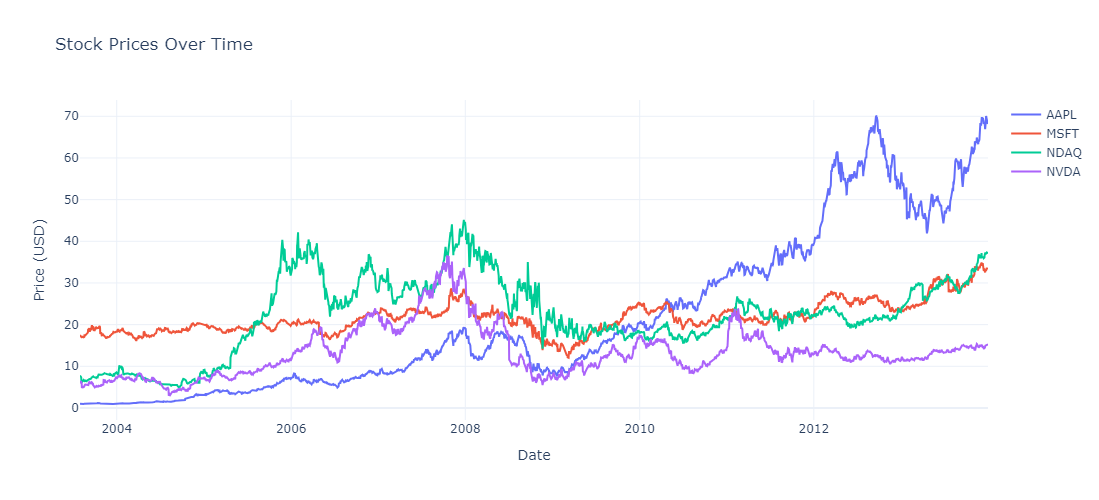

In [1]:
import pandas as pd
import plotly.graph_objects as go

# load the data using pandas. 
df = pd.read_csv("stock_prices.csv", parse_dates=["Date"])
mm = df.set_index("Date")  # The function of df.set_index will retun a new dataframe. And raises the data column as index colun
nn = mm.loc[mm.index > "2013-12-31"]
mm = mm.loc[mm.index <= "2013-12-31"]


fig = go.Figure()

# Now we want to do some data visualization, I want to predict the stock price of Apple,using NVDIA, Microsoft stock prices and the NASDAQ index to help train the model.

# Here you can also hover the mouse on data, and it shows corresponding information.
for col in ["AAPL", "MSFT", "NDAQ","NVDA"]:
    fig.add_trace(go.Scatter(
        x=mm.index,
        y=mm[col],
        mode="lines",
        name=col,
        hovertemplate=
            "Date: %{x}<br>" +
            f"{col} Price: "+"%{y:.2f}<extra></extra>"
    ))


fig.update_layout(
    title="Stock Prices Over Time",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    hovermode="x unified",  
    template="plotly_white",
    xaxis=dict(hoverformat="%Y-%m-%d"),
    height=500,
    width=1000
)

fig.show()
# Here you get the visualization of the four attributes. It is clearly that Apple stock price is increasing fast.Because it is only for data visualization
# And we use the data before and include 2013-12-31 to visualize

In [2]:
print(len(nn)) # just to check

252


Text(0.5, 1.0, 'Log of AALP before 2013-12-31 with the trend line')

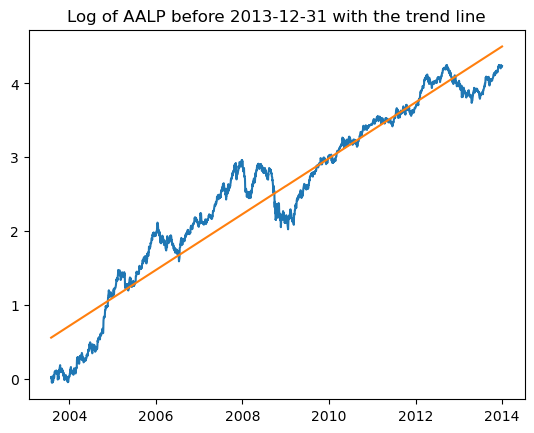

In [3]:
# after first differencing of the apple stock price and visualize the data 
# Note: mm here, followed by the first block is all the data before 2012-12-31. I have manually divided it. 
from sklearn import linear_model as lm
import matplotlib.pyplot as plt
import numpy as np

y1 = mm["AAPL"].values
y_log = np.log(y1[1:])-np.log(y1[:-1])
my = np.log(df["AAPL"]).diff().dropna()
xIndex1 = mm.index[1:]
xIndex2 = df.index[:]
plt.plot(mm.index, np.log(y1))
X = mm.index.map(lambda d: d.year + d.dayofyear / 365).values.reshape(-1, 1)
reg = lm.LinearRegression()
reg.fit(X, np.log(y1))
y_trend = reg.predict(X)
plt.plot(mm.index, y_trend)
plt.title("Log of AALP before 2013-12-31 with the trend line")

# This is the log of the stock prices of AAPL, the axis is day by unit

In [4]:
print(y_log.shape)
print(xIndex1.shape)

(2623,)
(2623,)


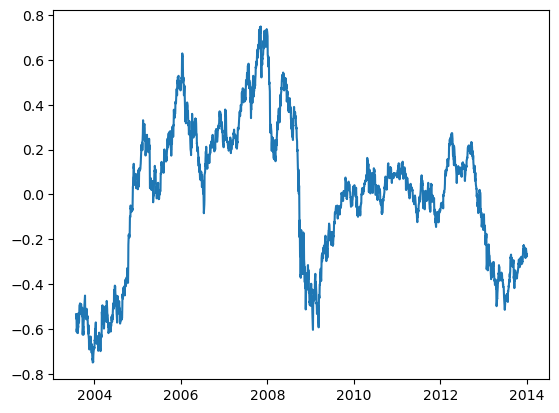

In [5]:
# Residuals after removing trend via linear regression
yRes = np.log(y1)-y_trend
plt.plot(mm.index, yRes)

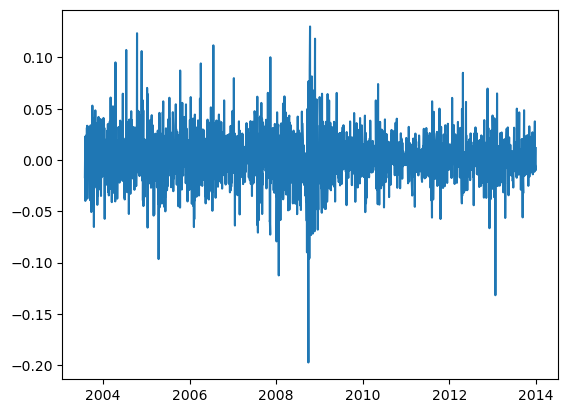

In [6]:
# This is the visualization of the AAPL after differencing once
# we can see after differencing once, it is considered as stationary.
plt.plot(xIndex1, y_log)

C:\Users\shang\anaconda3\Lib\site-packages\pmdarima\utils\visualization.py:220: FutureWarning:

the 'unbiased' keyword is deprecated, use 'adjusted' instead.



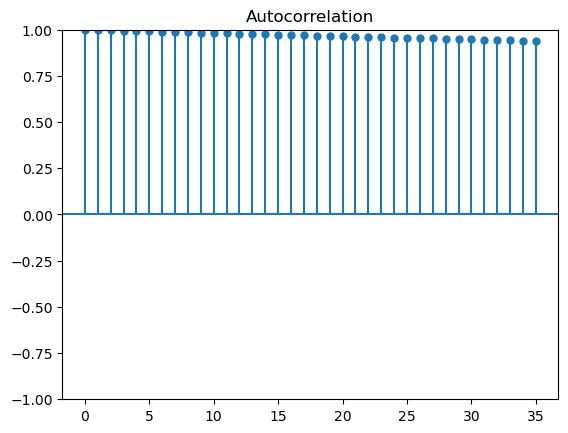

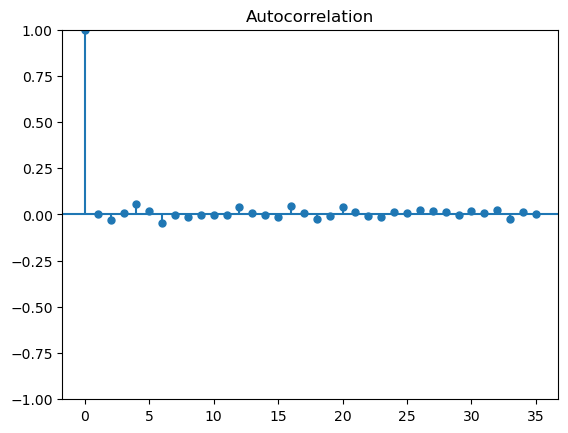

In [7]:
# We can tell now it is considered stationary, the acf strongly supports this.
import pmdarima as pm
import matplotlib.pyplot as plt
pm.utils.plot_acf(y1)
pm.utils.plot_acf(y_log) 
#  The first one is the acf before differencing, you can easily observe a trend here
# The second pic is the acf after differencing once, you can clearly see there is stationary. 

In [8]:
# Let us have more visualization data, inspiration from what we have done in class for time series.
# The following block is the visualization for MSFT,NVDA< and NDAQ.

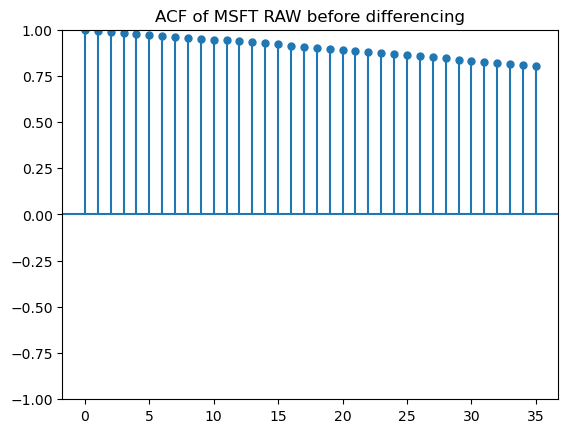

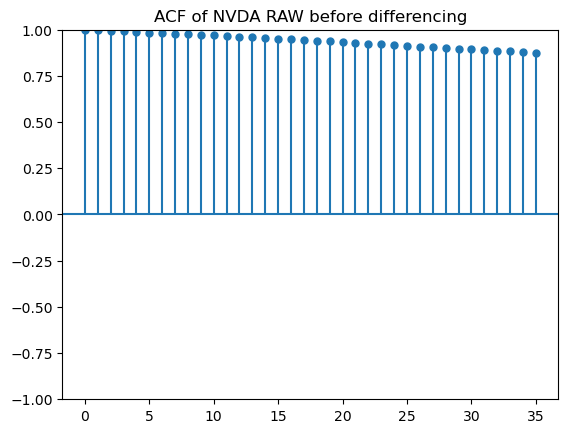

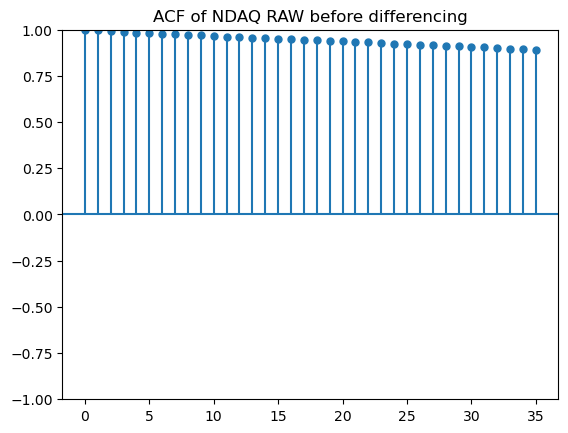

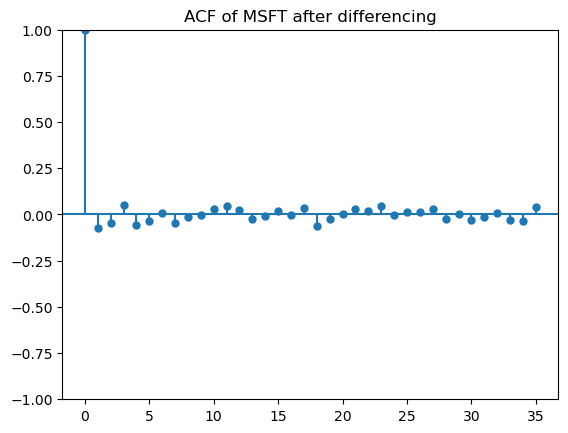

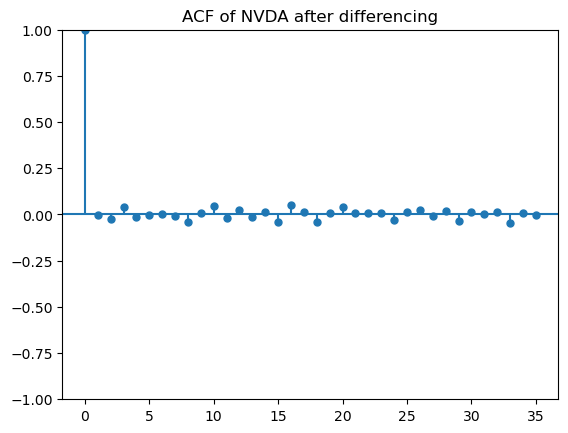

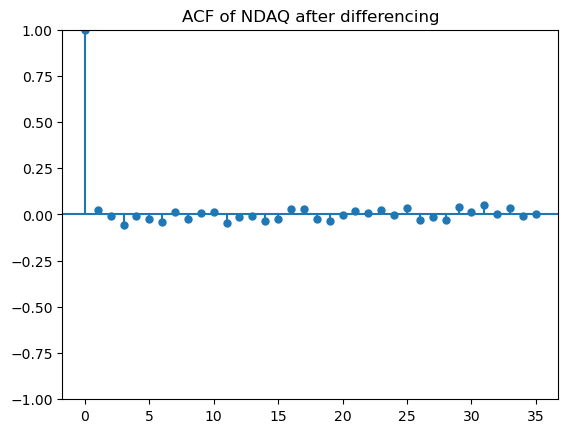

In [9]:
# now let us check the acf of other three attributes: Microsoft, NVIDA and NASDAQ
# well after differencing once, it seems the lag 1 still has strong correlation. 
# Our logic is that to stationalize the explanatory variable and then apply the ARIMAX model. 
# mm is the dataframe that considers data before 2013-12-31, or you could consider the training dataset(before2013-12-31).
pm.utils.plot_acf(mm['MSFT'].values, title = 'ACF of MSFT RAW before differencing')

pm.utils.plot_acf(mm['NVDA'].values, title = 'ACF of NVDA RAW before differencing')
pm.utils.plot_acf(mm['NDAQ'].values, title = 'ACF of NDAQ RAW before differencing')
y2 = np.log(mm['MSFT'].values)
y3 = np.log(mm['NVDA'].values)
y4 = np.log(mm['NDAQ'].values)
y2 = y2[1:]-y2[:-1]
y3 = y3[1:]-y3[:-1]
y4 = y4[1:]-y4[:-1]

pm.utils.plot_acf(y2, title = "ACF of MSFT after differencing") # This is to show the visual of MSFT after differencing, you can see it could be considered as stationary

pm.utils.plot_acf(y3, title = "ACF of NVDA after differencing")  # This is to show the visual of NVDA after differencing, you can see it could be considered as stationary

pm.utils.plot_acf(y4, title = "ACF of NDAQ after differencing")  # This is to show the visual of NDAQ after differencing, you can see it could be considered as stationary

# You cans see the acf demonstrates little correlation with time lag, combining with their data plots, it is good to say the processed data is stationary now.


In [10]:
# HERE, we divide the training datasets and testing dataset, in the training dataset, we also divide it to training and validation dataset. 
# Here you can see different attributes we consider(time series that is divided by a certain time mark)
# Note: here I did not clean all the data becasue I think all values should be considered to help predict the stock price. 
from pandas.tseries.frequencies import to_offset
aapl = mm["AAPL"]
msft = mm["MSFT"]
nvda = mm["NVDA"]
ndaq = mm["NDAQ"]
hp = mm["HP"]
aapl1 = nn["AAPL"]
msft1 = nn["MSFT"]
nvda1 = nn["NVDA"]
ndaq1 = nn["NDAQ"]
# This is for the training dataset after we choose the best model and predict on test dataset
train_full = np.log(aapl.loc[:"2013-12-31"]) # This is the whole training sets.

# This is the train_actual and train_val(validation dataset in training dataset)
train_actual = np.log(aapl.loc[:"2012-12-31"])
train_actual_diff = train_actual.diff().dropna()
train_validate = np.log(aapl.loc["2012-12-31":"2013-12-31"])
train_validate_diff = np.log(aapl.loc["2012-12-31":"2013-12-31"])
train_hp = np.log(hp.loc[:"2012-12-31"])
train_hp_val = np.log(hp.loc["2012-12-31":"2013-12-31"])
train_full_x1 = np.log(msft.loc[:"2013-12-31"])
train_full_x2 = np.log(nvda.loc[:"2013-12-31"])
train_full_x3 = np.log(ndaq.loc[:"2013-12-31"])
test_x1 = np.log(msft1.loc["2014-01-02":])
test_x2 = np.log(nvda1.loc["2014-01-02":])
test_x3 = np.log(ndaq1.loc["2014-01-02":])
train_x1 =(np.log(msft.loc[:"2012-12-31"]))
train_x2 = np.log(nvda.loc[:"2012-12-31"])
train_x3 = np.log(ndaq.loc[:"2012-12-31"])
train_x1_val = np.log(msft.loc["2012-12-31":"2013-12-31"])
train_x2_val = np.log(nvda.loc["2012-12-31":"2013-12-31"])
train_x3_val = np.log(ndaq.loc["2012-12-31":"2013-12-31"])
x1 = np.log(df.loc[:"2012-12-31", "MSFT"])
x1_val = np.log(df.loc["2013-01-01":"2013-12-31", "MSFT"])
print(len(train_validate))
# above is for choosing the model, evaluating on validation dataset

# below is the for evaluation on testing dataset
test_dataset = np.log(aapl1.loc["2014-01-02":])


# This function is used to solve the warning, by passing into the index that auto-arima could recognzie.
def strip_index(s):
    return pd.Series(s.values, index=np.arange(len(s)))
train_actual = strip_index(train_actual)
train_validate = strip_index(train_validate)
train_x1 = strip_index(train_x1)
train_x1_val = strip_index(train_x1_val)
train_x2 = strip_index(train_x2)
train_x2_val = strip_index(train_x2_val)
train_x3 = strip_index(train_x3)
train_x3_val = strip_index(train_x3_val)
train_full = strip_index(train_full)
test_dataset = strip_index(test_dataset)
train_hp = strip_index(train_hp)
train_hp_val = strip_index(train_hp_val)
train_full_x1 = strip_index(train_full_x1 )
train_full_x2 = strip_index(train_full_x2)
train_full_x3 = strip_index(train_full_x3)
train_x1_val = strip_index(train_x1_val)
train_x2_val = strip_index(train_x2_val)
train_x3_val = strip_index(train_x3_val)



print(len(test_dataset))



253
252


In [11]:
print(aapl.index.min())  # the earlist date
print(aapl.index.max())  # the latest date
# just to check if there is error
print(len(train_actual))


2003-07-31 00:00:00
2013-12-31 00:00:00
2372


In [12]:
#First we follow the advice of homework3, which is to build a model without additional time series first and then in the following blocks, we will extend the model.

In [13]:
from pmdarima.metrics import smape


In [14]:
# This is to use the time series of AAPL itself.
# Let us see how the pass values could explain the point. 

from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
model1 = auto_arima(train_actual, max_order=5,seasonal = False, stepwise = True, trace= False)

#next we use SARIMAX
model = SARIMAX(train_actual, order=model1.order, enforce_stationarity=False, enforce_invertibility=False)
result = model.fit(disp=False, maxiter=1000)

n_valid = len(train_validate)
start = len(train_actual)
end = n_valid + start-1
forecast = result.predict(start = start, end = end)

true = train_validate.values
mae = mean_absolute_error(true, forecast)
rmse = np.sqrt(mean_squared_error(true, forecast))
smape = 100 * np.mean(2 * np.abs(true - forecast) / (np.abs(true) + np.abs(forecast)))

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape:.2f}%")
# The smape is 3.03%, we can see it is good already, with performance metric performs good.

MAE: 0.1208, RMSE: 0.1364, SMAPE: 3.03%


In [15]:
# Now we consider additional time series. We still train on the actual training dataset and evaluate on the validation dataset first.
# Note the following blocks are made to choose the best model.
# We extend the model to consider the time series of MSFT, NVDA, NDAQ together. 
from pmdarima import auto_arima  
X_concatenate = np.concatenate(
    [train_x1.values.reshape(-1, 1),train_x2.values.reshape(-1,1), train_x3.values.reshape(-1, 1)],
    axis=1
)
test_model = auto_arima(train_actual,exogenous=X_concatenate,seasonal = False, stepwise = True, trace = True)
print("We first get thea best order than we do the SARMAX, the best order(p,d,q) would be: ",test_model.order)

model2 = SARIMAX(train_actual,exog=X_concatenate, order=test_model.order)
result = model2.fit(disp=False,maxiter=1000)
n_valid = len(train_validate)
start = len(train_actual)
end = n_valid + start-1
X_validate = np.concatenate(
    [train_x1_val.values.reshape(-1, 1), train_x2_val.values.reshape(-1, 1), train_x3_val.values.reshape(-1, 1)],
    axis=1)
forecast = result.predict(start = start, end = end, exog = X_validate)
true = train_validate_diff.values
mae = mean_absolute_error(true, forecast)
rmse = np.sqrt(mean_squared_error(true, forecast))
smape = 100 * np.mean(2 * np.abs(true - forecast) / (np.abs(true) + np.abs(forecast)))

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape:.2f}%")

print(result.summary())


# Here we can see the MAE, RMSE, SMAPE are slightly bigger than the model using AAPL itself,automatically we try to think to use feature engineering,to see if it is going to make the model better.

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-10998.400, Time=7.27 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-10998.115, Time=0.63 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-10996.127, Time=0.75 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-10996.122, Time=0.55 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-10988.299, Time=0.16 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-10992.540, Time=3.01 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-10994.086, Time=1.00 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-10996.847, Time=7.76 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-10998.374, Time=6.35 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-10994.439, Time=2.75 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-10993.830, Time=6.11 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-10992.940, Time=0.89 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=-10996.881, Time=10.09 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=-10988.527, Time=4.97 sec

Bes

In [16]:
# We try with feature engineering:  MSFT*MSFT,NVDA*NVDA, NDAQ*NDAQ, MSFT*NDAQ,MSFT*NVDA, NVDA*NDAQ as the current attributes
from pmdarima import auto_arima  
a = train_x1.values.reshape(-1, 1)
b = train_x2.values.reshape(-1,1)
c = train_x3.values.reshape(-1, 1)
a_val = train_x1_val.values.reshape(-1, 1)
b_val = train_x2_val.values.reshape(-1,1)
c_val = train_x3_val.values.reshape(-1, 1)
X_concatenate = np.concatenate(
    [a*a,b*b, c*c, a*b, a*c, b*c], axis=1
)
test_model = auto_arima(train_actual,exogenous=X_concatenate,seasonal = False, stepwise = True, trace = True)
print("We first get thea best order than we do the SARMAX, the best order(p,d,q) would be: ",test_model.order)

model2 = SARIMAX(train_actual,exog=X_concatenate, order=test_model.order)
result = model2.fit(disp=False,maxiter=1000)
n_valid = len(train_validate)
start = len(train_actual)
end = n_valid + start-1
X_validate = np.concatenate(
    [a_val*a_val,b_val*b_val, c_val*c_val, a_val*b_val, a_val*c_val, b_val*c_val],
    axis=1)
forecast = result.predict(start = start, end = end, exog = X_validate)
true = train_validate_diff.values
mae = mean_absolute_error(true, forecast)
rmse = np.sqrt(mean_squared_error(true, forecast))
smape = 100 * np.mean(2 * np.abs(true - forecast) / (np.abs(true) + np.abs(forecast)))

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape:.2f}%")

print(result.summary())


# After feature engineering the error is slightly larger, therefore, without feature engineering like this would be better. 

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-10998.400, Time=6.89 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-10998.115, Time=0.59 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-10996.127, Time=0.65 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-10996.122, Time=0.55 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-10988.299, Time=0.15 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-10992.540, Time=2.99 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-10994.086, Time=0.96 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-10996.847, Time=6.94 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-10998.374, Time=5.74 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-10994.439, Time=2.45 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-10993.830, Time=6.27 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-10992.940, Time=1.04 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=-10996.881, Time=11.11 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=-10988.527, Time=5.15 sec

Bes

In [17]:
# Now we consider additional time series. We still train on the actual training dataset and evaluate on the validation dataset first.
# This is to use msft alone as explanatory variable. 
from pmdarima import auto_arima  

test_model = auto_arima(train_actual,exogenous=train_x1.values.reshape(-1, 1),seasonal = False, stepwise = True, trace = True)
print("We first get thea best order than we do the SARMAX, the best order(p,d,q) would be: ",test_model.order)

model2 = SARIMAX(train_actual,exog=train_x1.values.reshape(-1,1), order=test_model.order)
result = model2.fit(disp=False,maxiter=1000)
n_valid = len(train_validate)
start = len(train_actual)
end = n_valid + start-1
X_validate = np.concatenate(
    [train_x1_val.values.reshape(-1, 1), train_x2_val.values.reshape(-1, 1), train_x3_val.values.reshape(-1, 1)],
    axis=1)
forecast = result.predict(start = start, end = end, exog = train_x1_val.values.reshape(-1, 1))
true = train_validate.values
mae = mean_absolute_error(true, forecast)
rmse = np.sqrt(mean_squared_error(true, forecast))
smape = 100 * np.mean(2 * np.abs(true - forecast) / (np.abs(true) + np.abs(forecast)))

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape:.2f}%")

print(result.summary())


# Here we can see the MAE, RMSE, SMAPE is good. And the smape is the best so far. Perhaps, msft is more correlated with aapl.

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-10998.400, Time=7.38 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-10998.115, Time=0.80 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-10996.127, Time=0.72 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-10996.122, Time=0.59 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-10988.299, Time=0.19 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-10992.540, Time=2.93 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-10994.086, Time=1.02 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-10996.847, Time=7.64 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-10998.374, Time=5.84 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-10994.439, Time=2.51 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-10993.830, Time=5.70 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-10992.940, Time=0.94 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=-10996.881, Time=9.89 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=-10988.527, Time=4.58 sec

Best

C:\Users\shang\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\shang\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



MAE: 0.1534, RMSE: 0.1842, SMAPE: 3.83%
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2372
Model:               SARIMAX(2, 1, 2)   Log Likelihood                5749.284
Date:                Thu, 17 Apr 2025   AIC                         -11486.569
Time:                        22:24:48   BIC                         -11451.942
Sample:                             0   HQIC                        -11473.964
                               - 2372                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.6028      0.014     42.790      0.000       0.575       0.630
ar.L1         -0.1132      0.066     -1.705      0.088      -0.243       0.017
ar.L2       

In [18]:
# Next we try to find company hp and msft as additional time series.
X_c = np.concatenate([train_x1.values.reshape(-1,1), train_hp.values.reshape(-1,1)],axis =1)
X_v = np.concatenate([train_x1_val.values.reshape(-1,1), train_hp_val.values.reshape(-1,1)], axis=1)
print(1)

1


In [19]:
# Now we consider additional time series. We still train on the actual training dataset and evaluate on the validation dataset first.
# This is to use msft and hp together alone as explanatory variable. 
from pmdarima import auto_arima  
from statsmodels.tsa.statespace.sarimax import SARIMAX

test_model = auto_arima(train_actual,exogenous=X_c,seasonal = False, stepwise = True, trace = True)
print("We first get thea best order than we do the SARMAX, the best order(p,d,q) would be: ",test_model.order)

model2 = SARIMAX(train_actual,exog=X_c, order=test_model.order)
result = model2.fit(disp=False,maxiter=5000)
n_valid = len(train_validate)
start = len(train_actual)
end = n_valid + start-1
X_validate = np.concatenate(
    [train_x1_val.values.reshape(-1, 1), train_x2_val.values.reshape(-1, 1), train_x3_val.values.reshape(-1, 1)],
    axis=1)
forecast = result.predict(start = start, end = end, exog = X_v)
true = train_validate.values
mae = mean_absolute_error(true, forecast)
rmse = np.sqrt(mean_squared_error(true, forecast))
smape = 100 * np.mean(2 * np.abs(true - forecast) / (np.abs(true) + np.abs(forecast)))

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape:.2f}%")

print(result.summary())


# Here we can see the MAE, RMSE, SMAPE should be 

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-10998.400, Time=6.91 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-10998.115, Time=0.70 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-10996.127, Time=0.67 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-10996.122, Time=0.48 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-10988.299, Time=0.12 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-10992.540, Time=2.87 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-10994.086, Time=0.86 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-10996.847, Time=6.76 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-10998.374, Time=5.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-10994.439, Time=2.34 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-10993.830, Time=5.32 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-10992.940, Time=0.91 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=-10996.881, Time=9.93 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=-10988.527, Time=4.63 sec

Best

C:\Users\shang\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\Users\shang\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



MAE: 0.1619, RMSE: 0.1875, SMAPE: 4.03%
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2372
Model:               SARIMAX(2, 1, 2)   Log Likelihood                5809.832
Date:                Thu, 17 Apr 2025   AIC                         -11605.664
Time:                        22:25:47   BIC                         -11565.266
Sample:                             0   HQIC                        -11590.958
                               - 2372                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.4741      0.016     28.762      0.000       0.442       0.506
x2             0.1920      0.012     15.869      0.000       0.168       0.216
ar.L1       

C:\Users\shang\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [20]:
#After using additional time series to help examine the validation dataset, I find that the AAPL time series itself would be the best choice, as the model evaluation on validation dataset is the best. 

In [21]:
# Conclusion So far:#After comparing with using additional time series to help examine the validation dataset, I find that the AAPL time series itself would be the best choice, as the model evaluation on validation dataset is the best.
# However in this task, we are required to use additional time series to help predict, therefore, considering this, only include additional time series MSFT is the ideal choice.

In [22]:
# Now let us use the additional time series msft to help predict the aapl. 

In [23]:
print(train_full_x1.shape)
print("test_x1 shape:", test_x1.shape)
print("test_dataset shape:", test_dataset.shape)


(2624,)
test_x1 shape: (252,)
test_dataset shape: (252,)


In [24]:
# Note all the attributes you could have a detailed look at block 10. It's all written there with time index passed in;

In [25]:
# Let us test on testing dataset using our chosen model.
# Note: now we train on the whole training dataset: train_full

from pmdarima import auto_arima  

# test_model = auto_arima(train_full,exogenous=train_full_x1.values.reshape(-1, 1),seasonal = False, stepwise = True, trace = True)
# print("We first get thea best order than we do the SARMAX, the best order(p,d,q) would be: ",test_model.order)

model2 = SARIMAX(train_full,exog=train_full_x1.values.reshape(-1,1), order=(2,1,2))
result = model2.fit(disp=False,maxiter=1000)
n_valid = len(test_dataset)
start = len(train_full)
end = n_valid + start-1
forecast = result.predict(start = start, end = end, exog = test_x1.values.reshape(-1, 1))
true = test_dataset.values
mae = mean_absolute_error(true, forecast)
rmse = np.sqrt(mean_squared_error(true, forecast))
smape = 100 * np.mean(2 * np.abs(true - forecast) / (np.abs(true) + np.abs(forecast)))

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape:.2f}%")

print(result.summary())


# Here we get the result for the testing dataset.

MAE: 0.1439, RMSE: 0.1698, SMAPE: 3.24%
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2624
Model:               SARIMAX(2, 1, 2)   Log Likelihood                6373.967
Date:                Thu, 17 Apr 2025   AIC                         -12735.933
Time:                        22:25:53   BIC                         -12700.701
Sample:                             0   HQIC                        -12723.173
                               - 2624                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.5606      0.014     41.355      0.000       0.534       0.587
ar.L1         -0.1185      0.038     -3.120      0.002      -0.193      -0.044
ar.L2       

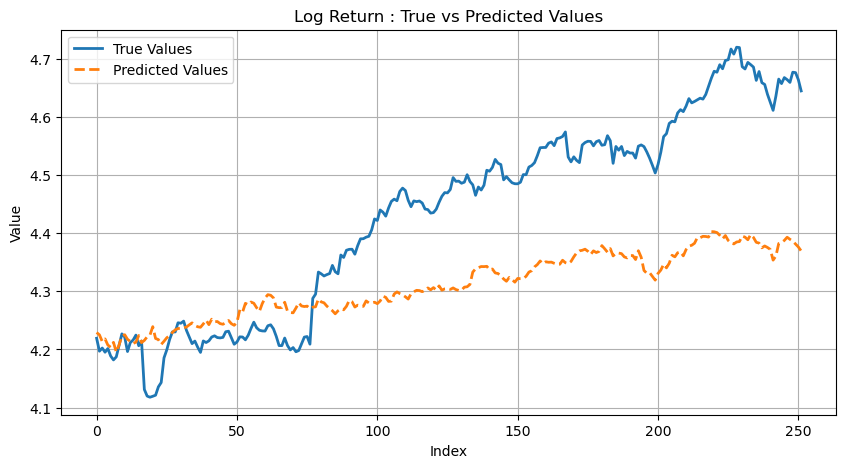

252


In [26]:
import numpy as np
import matplotlib.pyplot as plt
# Note the x axis is day by unit. 
x = np.arange(len(true))

plt.figure(figsize=(10, 5))
plt.plot(x, true, label='True Values', linewidth=2)
plt.plot(x, forecast, label='Predicted Values', linewidth=2, linestyle='--')
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Log Return : True vs Predicted Values")
plt.legend()
plt.grid(True)
plt.show()
print(len(true))


In [27]:
#Although the model's point predictions show a noticeable deviation from the true values,
#it effectively captures the underlying trend of the time series. 
#This indicates that while the model may currently lack in numerical precision, 
#it demonstrates a solid capacity in tracking directional movements, which provides a strong foundation for further refinement and optimization.
# Analyze:SARIMAX models linear dependencies. Real-world financial time series often exhibit nonlinear behaviors that this model class cannot fully capture.
# Also, we can see the residuals have a strong correlation, meaning that the model doesn't capture the rising trend. 
# Also, the market of stock is too large and have numerous factors contributing to the change of it, and itself is really hard to predict using SARIMAX mdoel.

MAE: 0.3026, RMSE: 0.3670, SMAPE: 6.37%


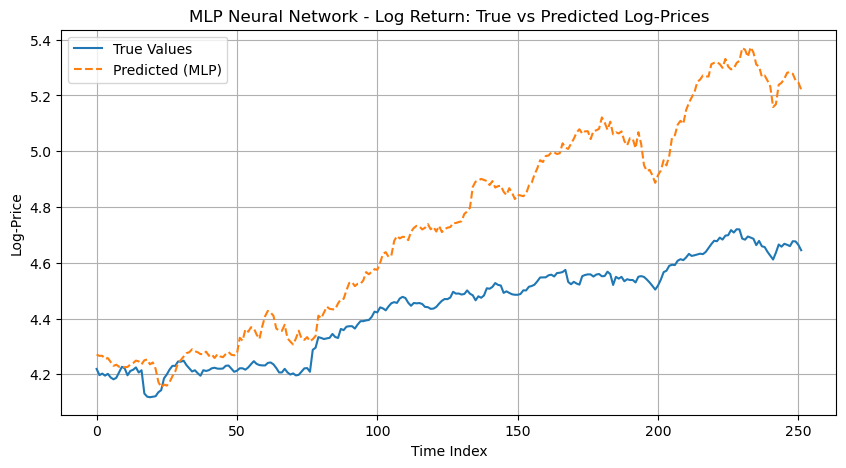

In [28]:
# Here we try to apply the knowledge learnt in class about neural network to make our prediction better. 
# We use activation funciton "Relu", and use only msft as 
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# The 
def window(y, x, window_size):
    X_combined, y_target = [], []
    for t in range(window_size, len(y)):
        past_y = y[t-window_size:t]             # shape = (window_size,)
        x_t = x[t].reshape(1,)                  # shape = (1,)
        combined = np.concatenate([past_y, x_t])  # shape = (window_size + 1,)
        X_combined.append(combined)
        y_target.append(y[t])
    return np.array(X_combined), np.array(y_target)
window_size = 8
#Here we didn't leak the test dataset so we are safe.
X_train, y_train = window(train_full, train_full_x1, window_size)
y_test_full = np.concatenate([train_full[-window_size:], test_dataset])
x_test_full = np.concatenate([train_full_x1[-window_size:], test_x1])
X_test, y_test = window(y_test_full, x_test_full, window_size)
scaler = StandardScaler()
# Here, we scale because we want to let the convergence happen fast. MLP use backpropagation and therefore will enlarge the effect of the bigger value, ignore the smaller value and therefore, it is better to scale it. 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
forecast = mlp.predict(X_test_scaled)
mae = mean_absolute_error(y_test, forecast)
rmse = np.sqrt(mean_squared_error(y_test, forecast))
smape = 100 * np.mean(2 * np.abs(y_test - forecast) / (np.abs(y_test) + np.abs(forecast)))
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape:.2f}%")
plt.figure(figsize=(10, 5))
plt.plot(y_test, label="True Values")
plt.plot(forecast, label="Predicted (MLP)", linestyle='--')
plt.title("MLP Neural Network - Log Return: True vs Predicted Log-Prices")
plt.xlabel("Time Index")
plt.ylabel("Log-Price")
plt.legend()
plt.grid(True)
plt.show()


MAE: 0.1581, RMSE: 0.1776, SMAPE: 3.43%


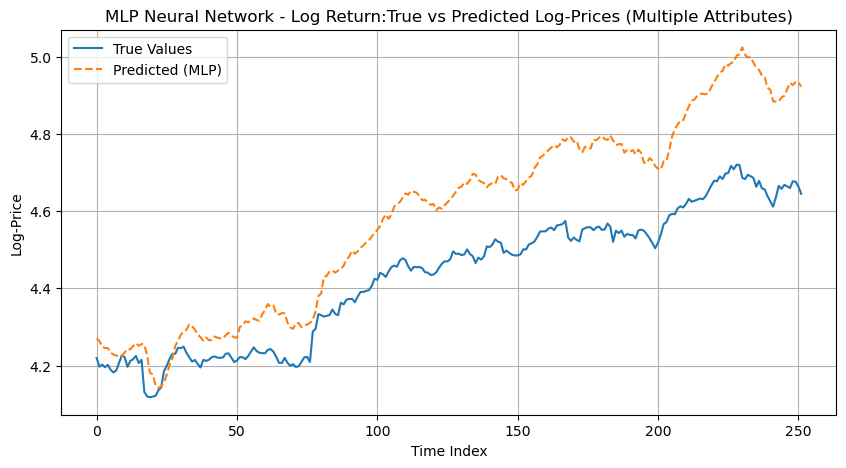

In [29]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
# Here we still use the neural network, and then we want to add more attributes to it to see if it predicts better. 
# Here is moving average model
def window(y, x_list, window_size):
    X_combined, y_target = [], []
    for t in range(window_size, len(y)):
        past_y = y[t-window_size:t]  
        past_x = [x[t].reshape(1,) for x in x_list] 
        x_t_all = np.concatenate(past_x) 
        combined = np.concatenate([past_y, x_t_all])  # shape = (window_size + num_exog,)
        X_combined.append(combined)
        y_target.append(y[t])
    return np.array(X_combined), np.array(y_target)
window_size = 5
X_train, y_train = window(
    train_full,
    [train_full_x1, train_full_x2, train_full_x3],
    window_size
)
y_test_full = np.concatenate([train_full[-window_size:], test_dataset])
x1_test_full = np.concatenate([train_full_x1[-window_size:], test_x1])
x2_test_full = np.concatenate([train_full_x2[-window_size:], test_x2])
x3_test_full = np.concatenate([train_full_x3[-window_size:], test_x3])

X_test, y_test = window(
    y_test_full,
    [x1_test_full, x2_test_full, x3_test_full],
    window_size
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)
forecast = mlp.predict(X_test_scaled)
mae = mean_absolute_error(y_test, forecast)
rmse = np.sqrt(mean_squared_error(y_test, forecast))
smape = 100 * np.mean(2 * np.abs(y_test - forecast) / (np.abs(y_test) + np.abs(forecast)))
print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape:.2f}%")
plt.figure(figsize=(10, 5))
plt.plot(y_test, label="True Values")
plt.plot(forecast, label="Predicted (MLP)", linestyle='--')
plt.title("MLP Neural Network - Log Return:True vs Predicted Log-Prices (Multiple Attributes)")
plt.xlabel("Time Index")
plt.ylabel("Log-Price")
plt.legend()
plt.grid(True)
plt.show()
# Here we use neural network to help better capture the trend. Afterall, trend is im

In [30]:
#this reinforces the notion that stock markets are inherently noisy and difficult to predict, especially using limited features and linear or shallow models.